# Hot Trend Lab Overview

This notebook is the executable entry point for the Hot Trend Lab column. It verifies the source registry, the real-data policy, the De-Time component contract, and the editorial scoring logic.

The column does not use synthetic fallback data. Every case notebook fetches real public data at runtime or stops with an explicit error.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prefer the checkout when this notebook is run inside the repository.
repo_root = Path.cwd()
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]:
    if (candidate / "src" / "detime").exists():
        repo_root = candidate
        break
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root))

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_language_guardrails

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = repo_root / "examples" / "hot_trends" / "cache"
OUTPUT_DIR = repo_root / "examples" / "hot_trends" / "outputs"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    relative_path = path.relative_to(repo_root).as_posix()
    print(f"saved: {relative_path}")


## 1. Source registry

The source registry is the minimum evidence object for this column. It tells readers what is being measured and what not to overclaim.


In [2]:
registry = pd.read_csv(repo_root / "examples" / "hot_trends" / "reports" / "source_registry.csv")
registry


,source,endpoint,notebooks,real_data_policy,freshness,caveat
0,arXiv API,https://export.arxiv.org/api/query,"01,02",live public API; no synthetic fallback,weekly/monthly,preprints are not peer-reviewed; cross-listing...
1,arXiv monthly submissions,https://arxiv.org/show_monthly_submissions,"00,01",official public stats page,monthly,"global totals, not category-level time series"
2,Hugging Face Hub API,https://huggingface.co/api/models,03,live public API; repeated snapshots needed for...,daily/weekly,downloads and likes are adoption proxies
3,GitHub REST API,https://api.github.com/repos/{owner}/{repo}/st...,04,live public API; token recommended,weekly,"stars are attention, not usage"
4,Wikimedia Analytics API,https://wikimedia.org/api/rest_v1/metrics/page...,05,live public API,daily/weekly,"pageviews are attention, not importance"
5,DeFiLlama stablecoin API,https://stablecoins.llama.fi/stablecoins?inclu...,06,live public API,daily/weekly,API schema should be checked before publication
6,CoinGecko API,https://api.coingecko.com/api/v3/coins/{id}/ma...,06,live public API,per run,rate limits and plan limits apply
7,Yahoo Finance via yfinance,yfinance.download,07,live public market data via yfinance; no price...,per run,tutorial-grade source; use licensed vendor for...


## 2. Column priority matrix

The strongest first wave is arXiv because it combines public data, academic relevance, high AI traffic, and a clean trend/cycle/residual story.


In [3]:
priority = pd.DataFrame([
    {"rank": 1, "case": "arXiv category pulse", "why_it_can_pop": "AI paper growth is controversial, measurable, and easy to refresh.", "rendered_page": "notebooks/01_arxiv_category_pulse/"},
    {"rank": 2, "case": "AI agent research pulse", "why_it_can_pop": "Agent and coding-agent papers move quickly and map to active product debates.", "rendered_page": "notebooks/02_arxiv_agent_research_pulse/"},
    {"rank": 3, "case": "Hugging Face open-model pulse", "why_it_can_pop": "Open-model releases create visible download and like snapshots.", "rendered_page": "notebooks/03_huggingface_open_model_pulse/"},
    {"rank": 4, "case": "GitHub AI-agent star velocity", "why_it_can_pop": "Developer attention is high-signal for tooling narratives.", "rendered_page": "notebooks/04_github_ai_agent_star_velocity/"},
    {"rank": 5, "case": "Wikimedia attention decay", "why_it_can_pop": "Pageviews turn public hype into a measurable time series.", "rendered_page": "notebooks/05_wikipedia_attention_hype_decay/"},
    {"rank": 6, "case": "Crypto and stablecoin liquidity pulse", "why_it_can_pop": "Crypto liquidity moves fast and has strong public attention.", "rendered_page": "notebooks/06_crypto_stablecoin_liquidity_pulse/"},
    {"rank": 7, "case": "AI infrastructure market pulse", "why_it_can_pop": "AI infrastructure remains a major market narrative.", "rendered_page": "notebooks/07_ai_infrastructure_market_pulse/"},
])
priority


,rank,case,why_it_can_pop,rendered_page
0,1,arXiv category pulse,"AI paper growth is controversial, measurable, ...",notebooks/01_arxiv_category_pulse/
1,2,AI agent research pulse,Agent and coding-agent papers move quickly and...,notebooks/02_arxiv_agent_research_pulse/
2,3,Hugging Face open-model pulse,Open-model releases create visible download an...,notebooks/03_huggingface_open_model_pulse/
3,4,GitHub AI-agent star velocity,Developer attention is high-signal for tooling...,notebooks/04_github_ai_agent_star_velocity/
4,5,Wikimedia attention decay,Pageviews turn public hype into a measurable t...,notebooks/05_wikipedia_attention_hype_decay/
5,6,Crypto and stablecoin liquidity pulse,Crypto liquidity moves fast and has strong pub...,notebooks/06_crypto_stablecoin_liquidity_pulse/
6,7,AI infrastructure market pulse,AI infrastructure remains a major market narra...,notebooks/07_ai_infrastructure_market_pulse/


## Visualization: column priority score

The priority bar chart makes the editorial launch order explicit.

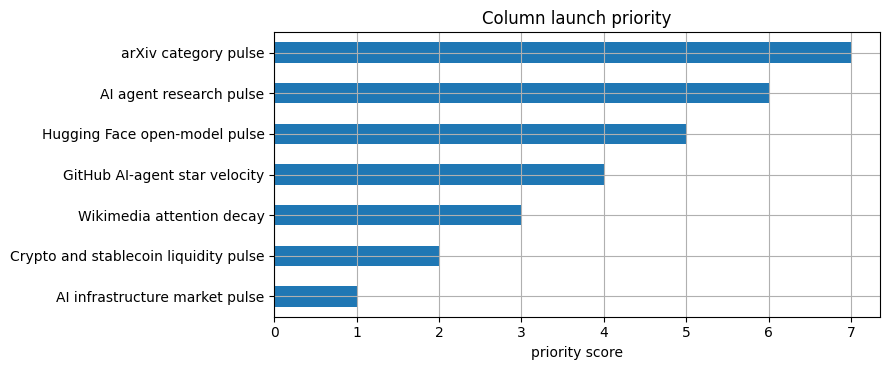

In [4]:
priority_plot = priority.assign(priority_score=len(priority) + 1 - priority["rank"]).sort_values("priority_score")
ax = priority_plot.plot(kind="barh", x="case", y="priority_score", figsize=(9, 3.8), legend=False, title="Column launch priority")
ax.set_xlabel("priority score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 3. De-Time output contract

Each notebook exports the same table types: source audit, component summary, residual events, and publication guardrails.


In [5]:
output_contract = pd.DataFrame([
    {"table": "source_audit", "purpose": "proves the table came from a real source and records coverage"},
    {"table": "component_summary", "purpose": "trend slope, cycle strength, residual shock score"},
    {"table": "residual_events", "purpose": "event-like deviations for article hooks"},
    {"table": "language_guardrails", "purpose": "safe wording for public posts"},
])
output_contract


,table,purpose
0,source_audit,proves the table came from a real source and r...
1,component_summary,"trend slope, cycle strength, residual shock score"
2,residual_events,event-like deviations for article hooks
3,language_guardrails,safe wording for public posts


## Visualization: output readiness matrix

The readiness matrix checks whether each case has produced its key real-data output files.

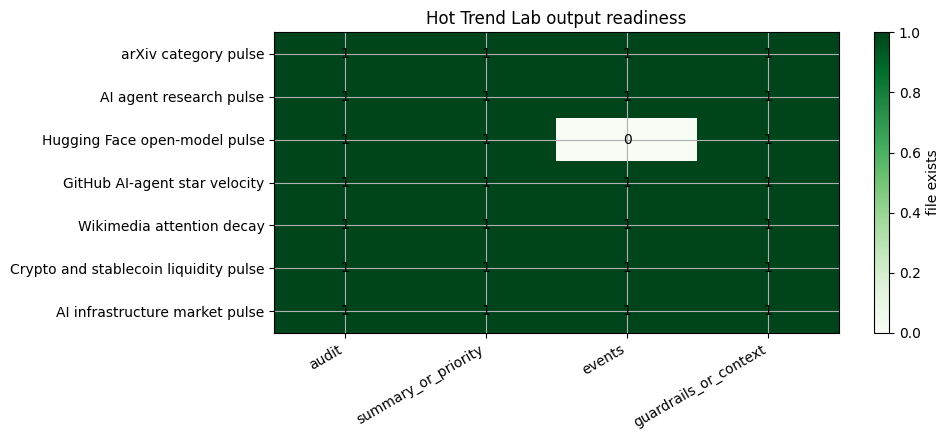

In [6]:
expected_outputs = pd.DataFrame([
    {"case": "arXiv category pulse", "audit": "01_arxiv_category_audit.csv", "summary_or_priority": "01_arxiv_category_priority.csv", "events": "01_arxiv_category_residual_events.csv", "guardrails_or_context": "01_arxiv_category_guardrails.csv"},
    {"case": "AI agent research pulse", "audit": "02_arxiv_agent_topic_audit.csv", "summary_or_priority": "02_arxiv_agent_topic_priority.csv", "events": "02_arxiv_agent_topic_residual_events.csv", "guardrails_or_context": "02_arxiv_agent_article_outline.csv"},
    {"case": "Hugging Face open-model pulse", "audit": "03_hf_snapshot_audit.csv", "summary_or_priority": "03_hf_decomposition_or_collection_status.csv", "events": "03_hf_residual_events.csv", "guardrails_or_context": "03_hf_guardrails.csv"},
    {"case": "GitHub AI-agent star velocity", "audit": "04_github_stargazer_coverage.csv", "summary_or_priority": "04_github_decomposition_or_collection_status.csv", "events": "04_github_residual_events.csv", "guardrails_or_context": "04_github_guardrails.csv"},
    {"case": "Wikimedia attention decay", "audit": "05_wikipedia_attention_audit.csv", "summary_or_priority": "05_wikipedia_attention_summary.csv", "events": "05_wikipedia_attention_events.csv", "guardrails_or_context": "05_wikipedia_guardrails.csv"},
    {"case": "Crypto and stablecoin liquidity pulse", "audit": "06_crypto_price_audit.csv", "summary_or_priority": "06_crypto_price_summary.csv", "events": "06_crypto_price_residual_events.csv", "guardrails_or_context": "06_defillama_stablecoin_context.csv"},
    {"case": "AI infrastructure market pulse", "audit": "07_ai_infra_market_audit.csv", "summary_or_priority": "07_ai_infra_component_summary.csv", "events": "07_ai_infra_residual_events.csv", "guardrails_or_context": "07_ai_infra_guardrails.csv"},
])
availability = expected_outputs.set_index("case").apply(lambda col: col.map(lambda filename: (OUTPUT_DIR / filename).exists())).astype(int)
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(availability.to_numpy(), cmap="Greens", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(availability.columns)))
ax.set_xticklabels(availability.columns, rotation=30, ha="right")
ax.set_yticks(range(len(availability.index)))
ax.set_yticklabels(availability.index)
for y in range(availability.shape[0]):
    for x in range(availability.shape[1]):
        ax.text(x, y, str(int(availability.iloc[y, x])), ha="center", va="center", color="black")
ax.set_title("Hot Trend Lab output readiness")
fig.colorbar(im, ax=ax, label="file exists")
plt.tight_layout()
plt.show()


## 4. Language guardrails


In [7]:
article_language_guardrails()


,unsafe,safer
0,This trend predicts the next price move.,This trend summarizes the observed public seri...
1,This model is better because it has more downl...,Downloads are a public adoption proxy and shou...
2,This repo is winning because stars are rising.,"Star velocity measures developer attention, no..."
3,This pageview spike proves importance.,Pageviews measure public attention during the ...
4,This residual is a buy signal.,This residual marks an event-like deviation fr...


In [8]:
save_table(registry, "00_source_registry")
save_table(priority, "00_hot_trend_priority")
save_table(output_contract, "00_output_contract")
save_table(article_language_guardrails(), "00_language_guardrails")


saved: examples/hot_trends/outputs/00_source_registry.csv
saved: examples/hot_trends/outputs/00_hot_trend_priority.csv
saved: examples/hot_trends/outputs/00_output_contract.csv
saved: examples/hot_trends/outputs/00_language_guardrails.csv
